In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def load_and_prepare_image(image_path):
    img_bgr = cv2.imread(image_path)
    
    if img_bgr is None:
        raise ValueError("Image not found. Please check the file path.")
        
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    img_512 = cv2.resize(img_gray, (512, 512))
    return img_512

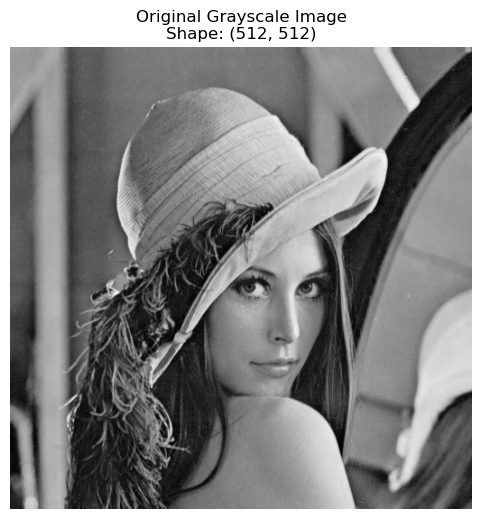

In [3]:
image_path = './Lenna_(test_image).png'  # after Downloading a standard 512x512 image
original_img = load_and_prepare_image(image_path)
    
plt.figure(figsize=(6, 6))
plt.imshow(original_img, cmap='gray')
plt.title(f"Original Grayscale Image\nShape: {original_img.shape}")
plt.axis('off')
plt.show()

In [4]:
def downsample_image(img, step_size):
    img_downsampled = img[::step_size, ::step_size]
    return img_downsampled

In [5]:
img_256 = downsample_image(original_img, 2)

In [6]:
img_128 = downsample_image(original_img, 4)

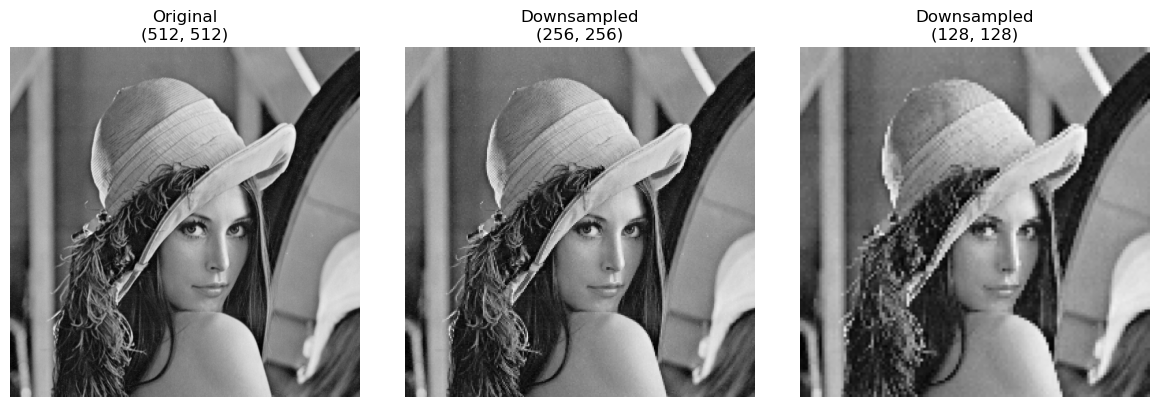

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(original_img, cmap='gray')
axes[0].set_title(f"Original\n{original_img.shape}")
axes[0].axis('off')

axes[1].imshow(img_256, cmap='gray')
axes[1].set_title(f"Downsampled\n{img_256.shape}")
axes[1].axis('off')

axes[2].imshow(img_128, cmap='gray')
axes[2].set_title(f"Downsampled\n{img_128.shape}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [8]:
def nearest_neighbour_scratch(img, target_size=(512, 512)):
    old_h, old_w = img.shape
    new_h, new_w = target_size
    
    row_ratio = old_h / new_h
    col_ratio = old_w / new_w
    
    new_rows = np.arange(new_h)
    new_cols = np.arange(new_w)
    
    old_rows = np.floor(new_rows * row_ratio).astype(int)
    old_cols = np.floor(new_cols * col_ratio).astype(int)
    
    upsampled_img = img[np.ix_(old_rows, old_cols)]
    
    return upsampled_img

In [9]:
def upsample_all_methods(img_small):
    img_nn = nearest_neighbour_scratch(img_small, (512, 512))
    
    img_bilinear = cv2.resize(img_small, (512, 512), interpolation=cv2.INTER_LINEAR)
    
    img_bicubic = cv2.resize(img_small, (512, 512), interpolation=cv2.INTER_CUBIC)
    
    return img_nn, img_bilinear, img_bicubic

In [10]:
nn_256, bil_256, bic_256 = upsample_all_methods(img_256)
nn_128, bil_128, bic_128 = upsample_all_methods(img_128)

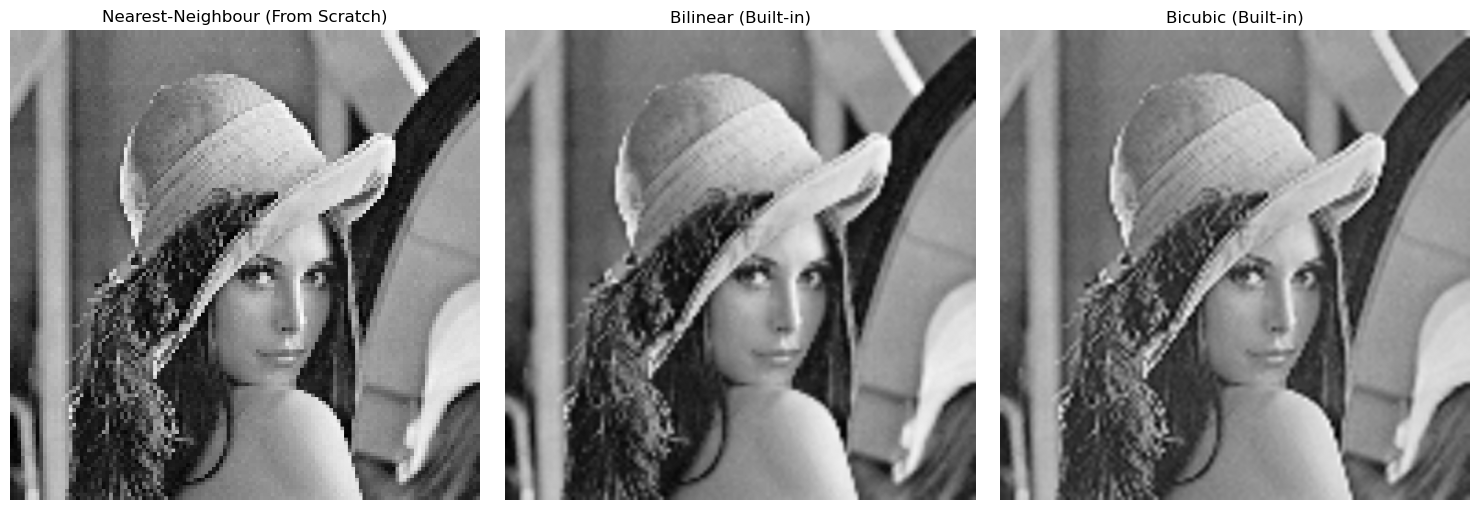

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(nn_128, cmap='gray')
axes[0].set_title("Nearest-Neighbour (From Scratch)")
axes[0].axis('off')

axes[1].imshow(bil_128, cmap='gray')
axes[1].set_title("Bilinear (Built-in)")
axes[1].axis('off')

axes[2].imshow(bic_128, cmap='gray')
axes[2].set_title("Bicubic (Built-in)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

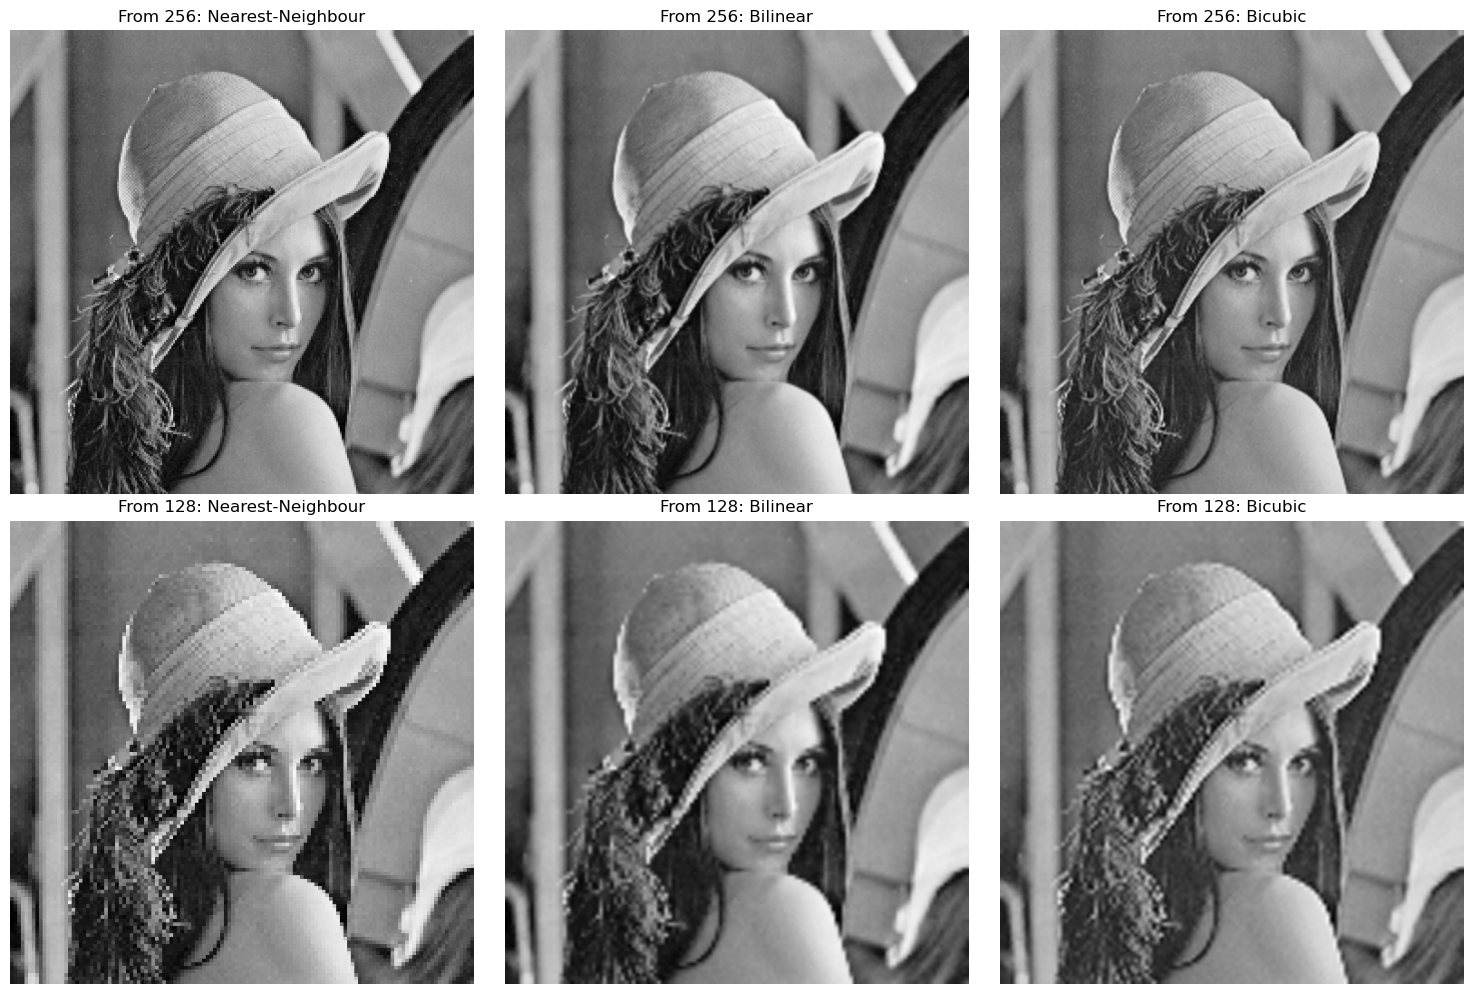

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(nn_256, cmap='gray')
axes[0, 0].set_title("From 256: Nearest-Neighbour")
axes[0, 0].axis('off')

axes[0, 1].imshow(bil_256, cmap='gray')
axes[0, 1].set_title("From 256: Bilinear")
axes[0, 1].axis('off')

axes[0, 2].imshow(bic_256, cmap='gray')
axes[0, 2].set_title("From 256: Bicubic")
axes[0, 2].axis('off')

axes[1, 0].imshow(nn_128, cmap='gray')
axes[1, 0].set_title("From 128: Nearest-Neighbour")
axes[1, 0].axis('off')

axes[1, 1].imshow(bil_128, cmap='gray')
axes[1, 1].set_title("From 128: Bilinear")
axes[1, 1].axis('off')

axes[1, 2].imshow(bic_128, cmap='gray')
axes[1, 2].set_title("From 128: Bicubic")
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

In [13]:
def calculate_mse(original, reconstructed):
    orig = original.astype(np.float64)
    recon = reconstructed.astype(np.float64)
    
    mse = np.mean((orig - recon) ** 2)
    return mse

def calculate_psnr(original, reconstructed):
    mse = calculate_mse(original, reconstructed)
    
    if mse == 0:
        return float('inf')
        
    max_pixel = 255.0
    psnr = 10 * np.log10((max_pixel ** 2) / mse)
    return psnr

In [16]:
reconstructions = [
    ("Nearest-Neighbour", "256x256", nn_256),
    ("Bilinear", "256x256", bil_256),
    ("Bicubic", "256x256", bic_256),
    ("Nearest-Neighbour", "128x128", nn_128),
    ("Bilinear", "128x128", bil_128),
    ("Bicubic", "128x128", bic_128)
]

results = []
for method, source_size, recon_img in reconstructions:
    mse_val = calculate_mse(original_img, recon_img)
    psnr_val = calculate_psnr(original_img, recon_img)
    results.append([method, source_size, round(mse_val, 2), round(psnr_val, 2)])

df_results = pd.DataFrame(results, columns=["Interpolation Method", "Source Size", "MSE", "PSNR (dB)"])
print(df_results.to_string(index=False))

Interpolation Method Source Size    MSE  PSNR (dB)
   Nearest-Neighbour     256x256  96.21      28.30
            Bilinear     256x256  61.92      30.21
             Bicubic     256x256  64.87      30.01
   Nearest-Neighbour     128x128 348.43      22.71
            Bilinear     128x128 231.68      24.48
             Bicubic     128x128 264.51      23.91


In [17]:
def generate_error_maps(original, recon):
    orig_f = original.astype(float)
    recon_f = recon.astype(float)
    
    abs_error = np.abs(orig_f - recon_f)
    sq_error = (orig_f - recon_f) ** 2
    
    return abs_error, sq_error

In [21]:
def plot_error_maps_for_group(original, recon_nn, recon_bil, recon_bic, title_prefix):
    abs_nn, sq_nn = generate_error_maps(original, recon_nn)
    abs_bil, sq_bil = generate_error_maps(original, recon_bil)
    abs_bic, sq_bic = generate_error_maps(original, recon_bic)
    
    fig, axes = plt.subplots(3, 2, figsize=(10, 12))
    fig.suptitle(f"Error Maps: {title_prefix}", fontsize=16)
    
    maps = [
        (abs_nn, sq_nn, "Nearest-Neighbour"),
        (abs_bil, sq_bil, "Bilinear"),
        (abs_bic, sq_bic, "Bicubic")
    ]
    
    for row, (abs_map, sq_map, method_name) in enumerate(maps):
        im_abs = axes[row, 0].imshow(abs_map, cmap='hot')
        axes[row, 0].set_title(f"{method_name}: Absolute")
        axes[row, 0].axis('off')
        fig.colorbar(im_abs, ax=axes[row, 0])
        
        im_sq = axes[row, 1].imshow(sq_map, cmap='hot')
        axes[row, 1].set_title(f"{method_name}: Squared")
        axes[row, 1].axis('off')
        fig.colorbar(im_sq, ax=axes[row, 1])
        
    plt.tight_layout()
    plt.show()

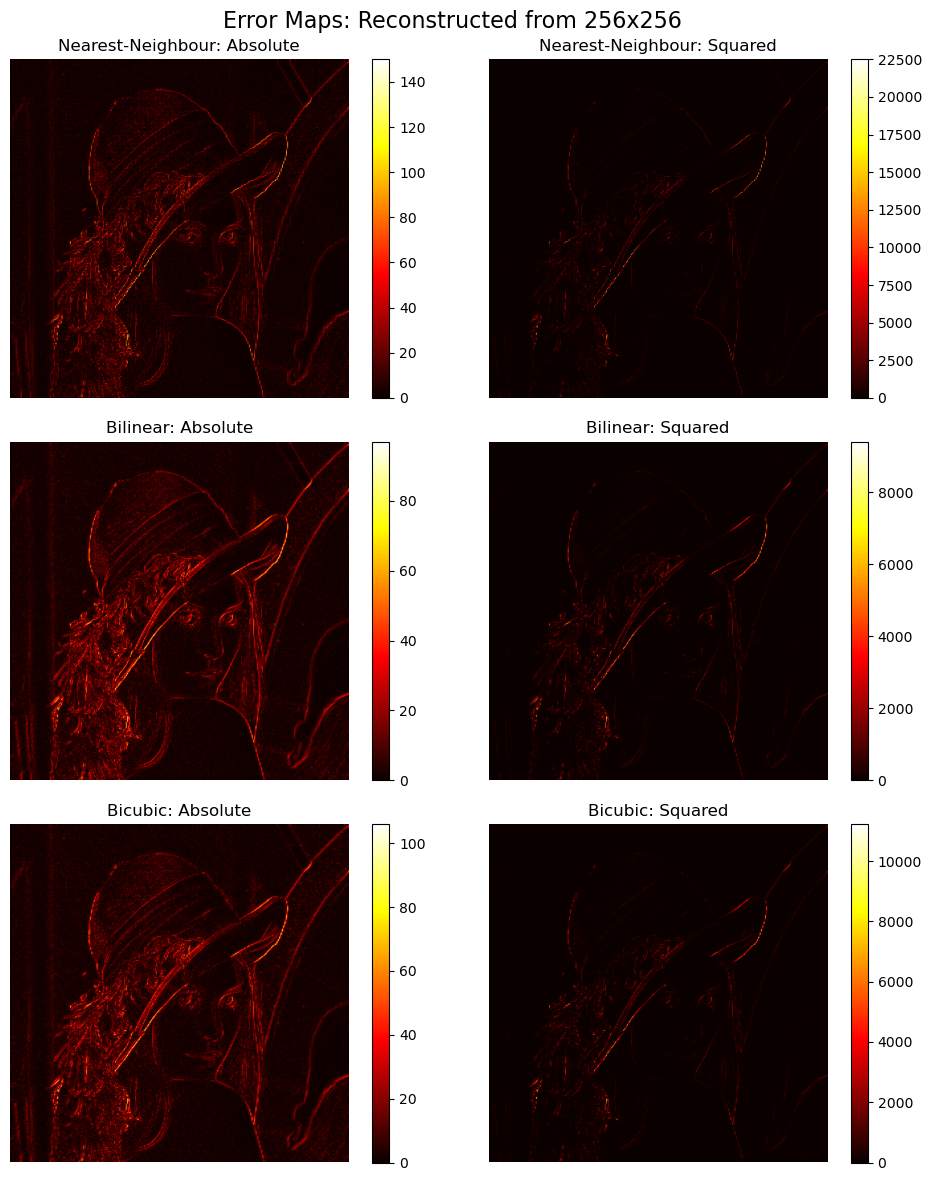

In [22]:
plot_error_maps_for_group(original_img, nn_256, bil_256, bic_256, "Reconstructed from 256x256")

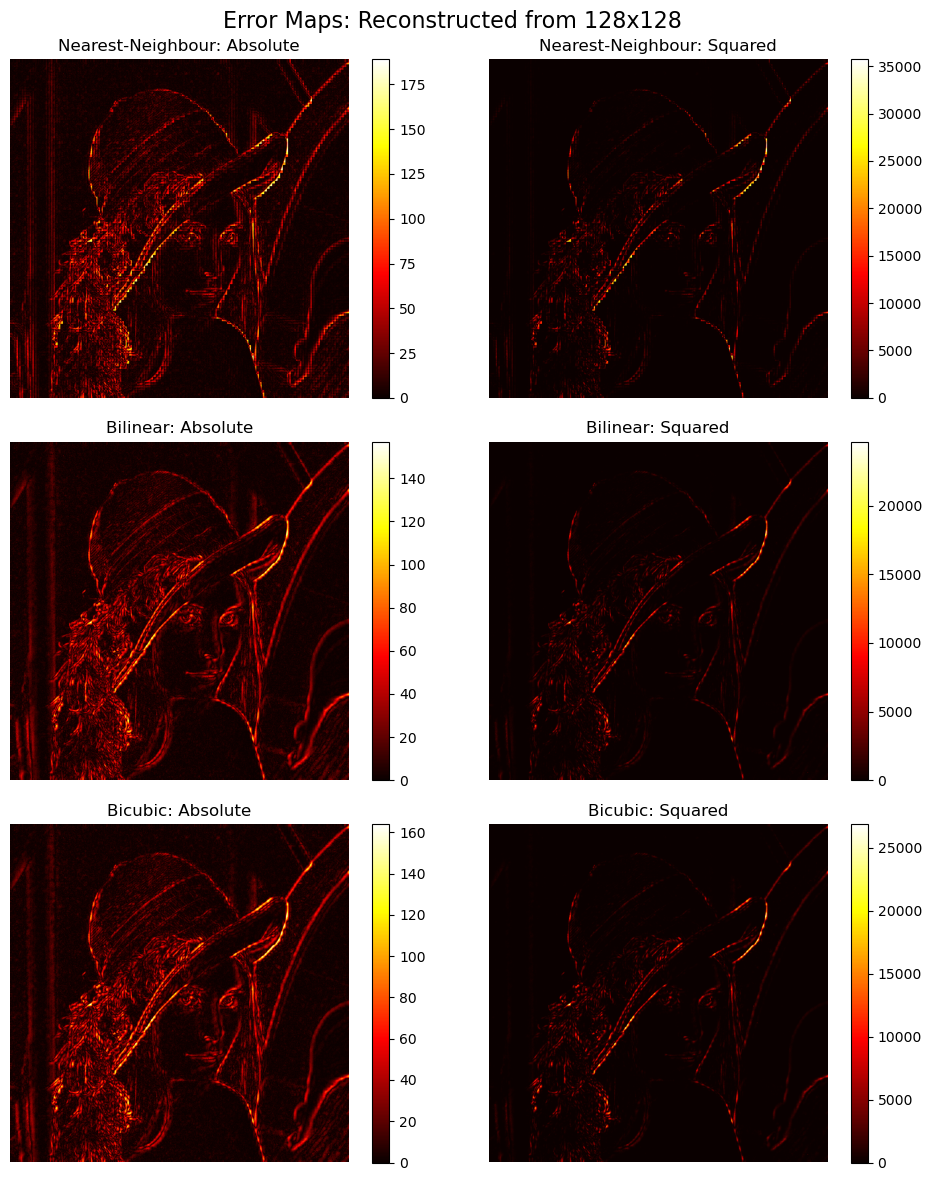

In [23]:
plot_error_maps_for_group(original_img, nn_128, bil_128, bic_128, "Reconstructed from 128x128")